# Lab 5: Clustering Algorithm

In [1]:
import pickle
import numpy as np

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Dataset A

#### Read the data

In [2]:
filename = "unknown_image_28x28_with_label_dataset_A.pkl"
with open(filename, 'rb') as f:
    image_with_label = pickle.load(f)

print(image_with_label.keys())

dict_keys(['image', 'label'])


(2195, 28, 28)


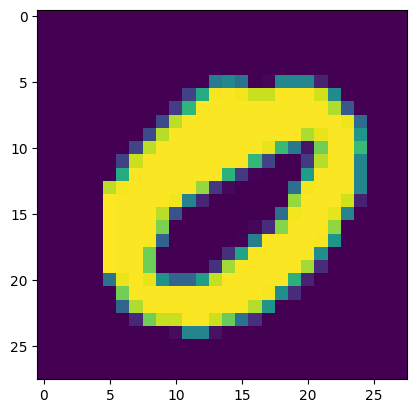

In [6]:
# You can uncomment the following to sneak into what these images are.
import random
an_unknown_set_of_images = image_with_label['image'].reshape(-1, 28, 28)
print(an_unknown_set_of_images.shape) # (จำนวนรูป, ความสูง, ความกว้าง)

random_number = random.randint(0, 2195) # สุ่มมาซักรูปมาดู แต่ละรูปขนาด (28 x 28 = 784 จุด pixels)
plt.imshow(an_unknown_set_of_images[random_number])

Note: ภาพมีขนาด 3 มิติ กว้างยาวสูง

## Principal components in the data with annotated clusters

Let's denote our data `image_with_label["image"]` as $ X \in \mathcal{R}^{n\times m}$ where $n = 784$ is the size of feature dimension.


Let us define the PCA transformation $Q:= [q_1, q_2] \in \mathcal{R}^{2\times n}$.

We will reduce the dimension of image features from 784 to 2 using PCA by multiplying them with $Q$


$ Z = Q^T X = [q_1, q_2]^T X $

Here each of $q_1, q_2$ is the principal component axis.

Then, the result of the transformation is $Z$, which is the reduced feature data samples $\in \mathcal{R}^{2\times m}$

In [8]:
m,n = image_with_label["image"].shape

print("The number of data samples: %d" % m)
print("The size of feature dimension: %d" % n)

The number of data samples: 2195
The size of feature dimension: 784


Before we apply the PCA, we need to standardize our data.
This can be done via `StandardScaler()` and its `fit_transform` operation.

In [9]:
scaler = StandardScaler()
image_2d_scaled = scaler.fit_transform(image_with_label["image"])

Now we are ready to apply PCA.

At first, we declear that we want only two principal component axes for $q_1, q_2$.

Thus, we use the command `pca = PCA(n_components=2)`

In [11]:
pca = PCA(n_components=2)
data_array_pca = pca.fit_transform(image_2d_scaled)
# pca = PCA(n_components=2).fit(X)
# Z = pca.components_@np.transpose(X)

`data_array_pca` is the result of the transformation ($Z$), which has the reduced feature dimension.

In [19]:
print(f"Dimension of Z = {data_array_pca.shape}")
print(f'Random Sample = {data_array_pca[random.randint(0, 2195)]}')

Dimension of Z = (2195, 2)
Random Sample = [9.91719223 1.85456612]


In [20]:
m_pca ,n_pca = data_array_pca.shape

print("The number of data samples: %d" % m_pca)
print("The size of reduced feature dimension: %d" % n_pca)

The number of data samples: 2195
The size of reduced feature dimension: 2


You can get the PCA transformation $Q:= [q_1, q_2] \in \mathcal{R}^{2\times n}$  from `pca.components_`

In [21]:
pca.components_

array([[ 9.54695959e-21, -9.68730230e-22, -3.80627200e-22, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [-3.27553318e-17,  1.19834588e-17,  5.64593768e-20, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [34]:
np.unique(image_with_label['label']) # [0, 1, 3, 4, 5, 9]

array([0, 1, 3, 4, 5, 9], dtype=uint8)

เรารู้ Cluster ที่แน่นอนอยู่แล้ว คือ k = 6 (จาก `Label`) เพราะฉะนั้น ตัว Model ที่ดีที่สุดมันควรจะให้ k = 6 ด้วย

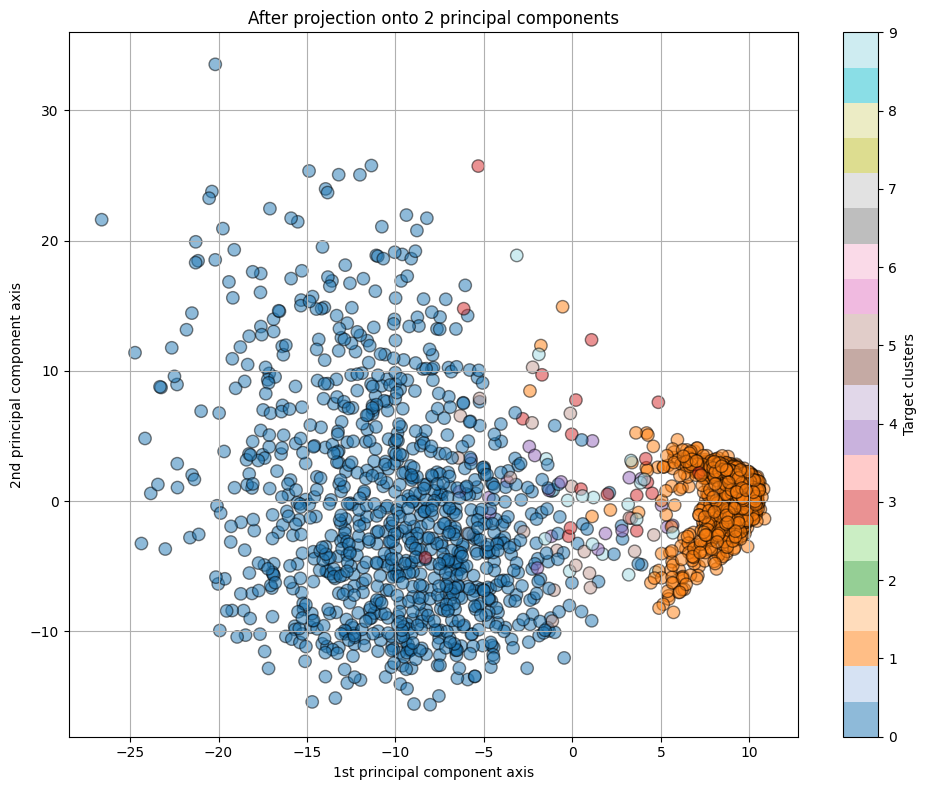

In [33]:
plt.figure(figsize=(10, 8))

plt.scatter(data_array_pca[:, 0], data_array_pca[:, 1], c=image_with_label["label"], cmap="tab20", edgecolor='k', s=80, alpha=0.5)
plt.xlabel('1st principal component axis')
plt.ylabel('2nd principal component axis')
plt.title('After projection onto 2 principal components')

plt.colorbar(label='Target clusters')
plt.grid()
plt.tight_layout()

## Candidate clustering algorithms

1. K-mean algorithm
2. Gaussian mixture model
3. DBSCAN

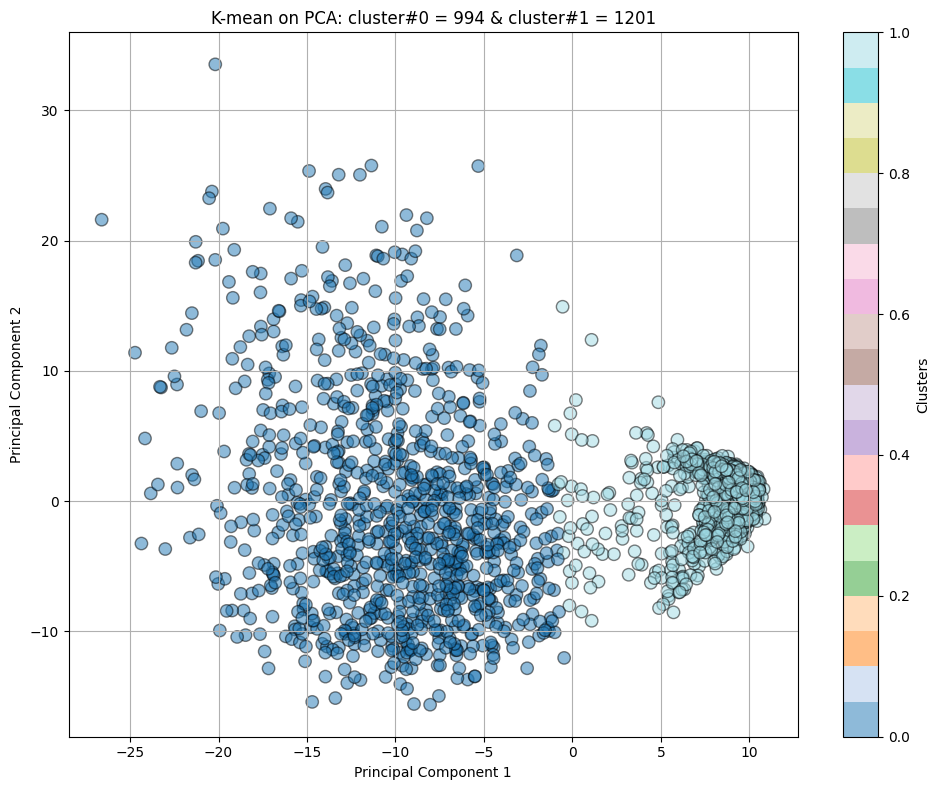

In [35]:
# K-mean algorithm
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(data_array_pca)
predicted_cluster =  kmeans.labels_

plt.figure(figsize=(10, 8))

plt.scatter(data_array_pca[:, 0], data_array_pca[:, 1],  c=predicted_cluster, edgecolor='k', cmap="tab20", s=80, alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-mean on PCA: cluster#0 = %d & cluster#1 = %d' % (sum(predicted_cluster == 0).item(), sum(predicted_cluster == 1).item()))


plt.colorbar(label='Clusters')
plt.grid()
plt.tight_layout()

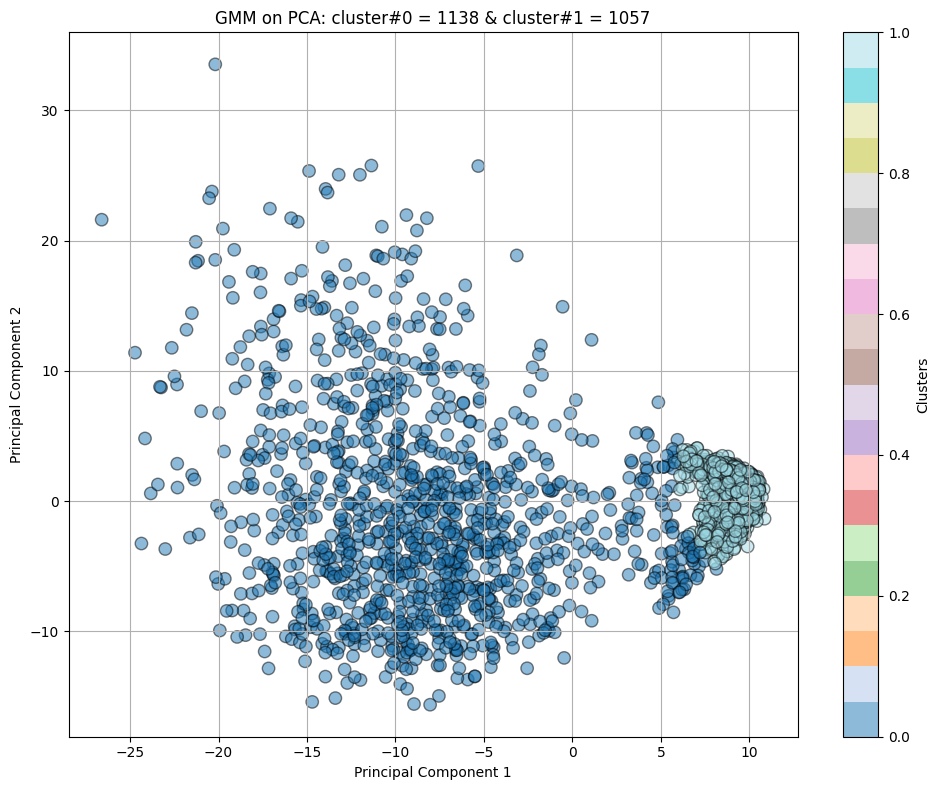

In [ ]:
# Gaussian mixture model
from sklearn.mixture import GaussianMixture
X      = data_array_pca
gm = GaussianMixture(n_components=2, random_state=0).fit(X)
predicted_cluster =  gm.predict(X)

plt.figure(figsize=(10, 8))

plt.scatter(data_array_pca[:, 0], data_array_pca[:, 1],  c=predicted_cluster, edgecolor='k', cmap="tab20", s=80, alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('GMM on PCA: cluster#0 = %d & cluster#1 = %d' % (sum(predicted_cluster == 0).item(), sum(predicted_cluster == 1).item()))


plt.colorbar(label='Clusters')
plt.grid()
plt.tight_layout()

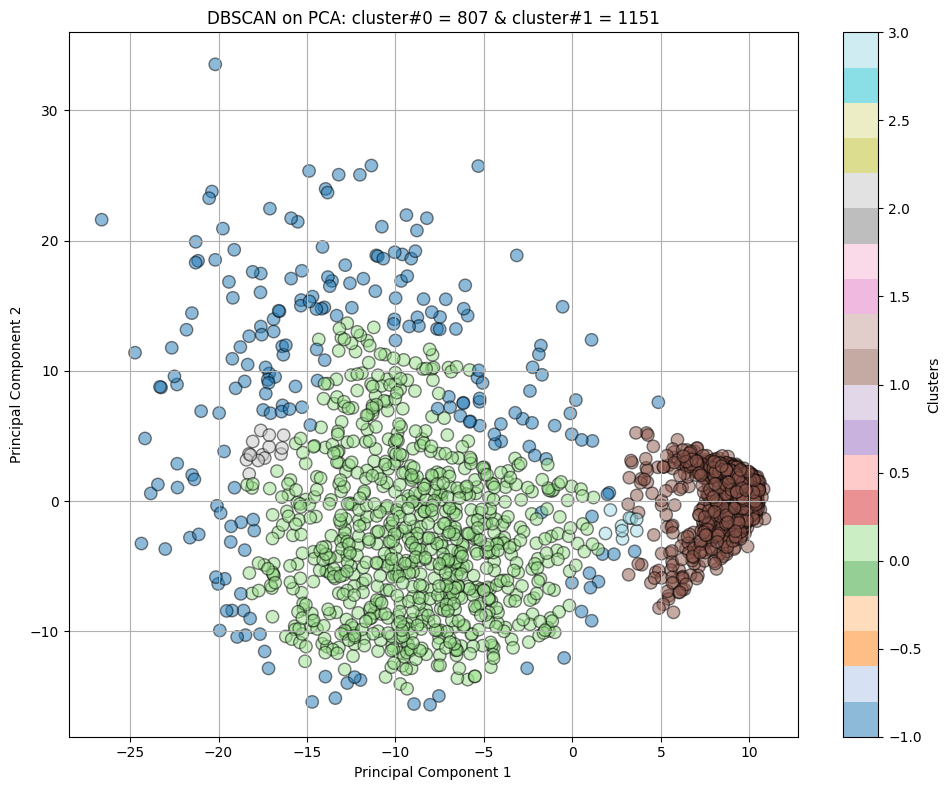

In [ ]:
# DBSCAN model
from sklearn.cluster import DBSCAN
X      = data_array_pca
dbscan = DBSCAN(eps=1.5, min_samples=10).fit(X)
predicted_cluster =  dbscan.labels_

plt.figure(figsize=(10, 8))

plt.scatter(data_array_pca[:, 0], data_array_pca[:, 1],  c=predicted_cluster, cmap="tab20", edgecolor='k', s=80, alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('DBSCAN on PCA: cluster#0 = %d & cluster#1 = %d' % (sum(predicted_cluster == 0).item(), sum(predicted_cluster == 1).item()))

plt.colorbar(label='Clusters')

plt.grid()
plt.tight_layout()

## Question 1

### Q1.1
When the number of clusters is **unknown**, what is the most suitable algorithm  (including the hyperparameter settings) ? Also, provide the reasons and evidence to support why the chosen algorithm is the most suitable for dataset A

#### Finding Optimal Hyperparameters for DBSCAN using Grid Search and Adjusted Rand Index

In [42]:
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd

X = data_array_pca
true_labels = image_with_label['label']

# Define the ranges for eps and min_samples to search
eps_range = np.arange(0.5, 5.0, 0.1)
min_samples_range = range(2, 15, 1)

best_ari = -1
best_eps = None
best_min_samples = None
all_results = []

print("Starting Grid Search for DBSCAN hyperparameters...")

for eps in eps_range:
    for min_samples in min_samples_range:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
        predicted_clusters = dbscan.labels_

        # Ignore cases where all points are noise (-1) or only one cluster is found (excluding noise)
        n_clusters = len(set(predicted_clusters)) - (1 if -1 in predicted_clusters else 0)
        if n_clusters < 2: # We expect at least two clusters to make sense for ARI comparison
            ari = -1 # Assign a low score if clustering is trivial
        else:
            ari = adjusted_rand_score(true_labels, predicted_clusters)

        all_results.append({'eps': eps, 'min_samples': min_samples, 'ari': ari})

        if ari > best_ari:
            best_ari = ari
            best_eps = eps
            best_min_samples = min_samples

results_df = pd.DataFrame(all_results)

print("Grid Search Complete.")
print(f"Best ARI: {best_ari:.4f}")
print(f"Best eps: {best_eps:.2f}")
print(f"Best min_samples: {best_min_samples}")

Starting Grid Search for DBSCAN hyperparameters...
Grid Search Complete.
Best ARI: 0.8317
Best eps: 1.70
Best min_samples: 11


### Visualization with Best DBSCAN Hyperparameters

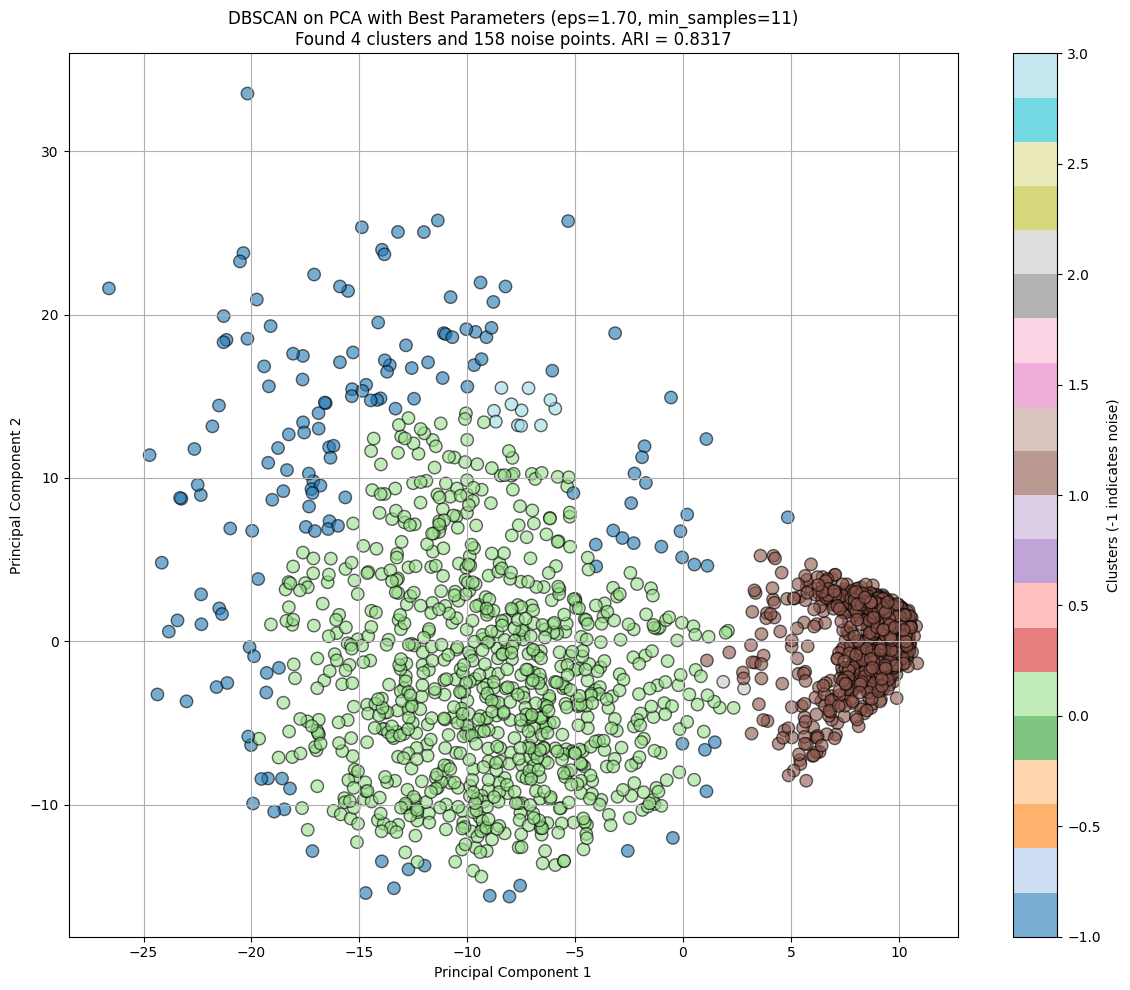


Top 5 results by ARI:


,eps,min_samples,ari
165,1.7,11,0.831699
151,1.6,10,0.827026
166,1.7,12,0.826926
50,0.8,13,0.826636
137,1.5,9,0.820975


In [43]:
plt.figure(figsize=(12, 10))

# Run DBSCAN with the best parameters found
dbscan_best = DBSCAN(eps=best_eps, min_samples=best_min_samples).fit(X)
predicted_cluster_best = dbscan_best.labels_

n_clusters_best = len(set(predicted_cluster_best)) - (1 if -1 in predicted_cluster_best else 0)
n_noise_best = list(predicted_cluster_best).count(-1)

plt.scatter(data_array_pca[:, 0], data_array_pca[:, 1], c=predicted_cluster_best, cmap="tab20", edgecolor='k', s=80, alpha=0.6)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'DBSCAN on PCA with Best Parameters (eps={best_eps:.2f}, min_samples={best_min_samples})\nFound {n_clusters_best} clusters and {n_noise_best} noise points. ARI = {best_ari:.4f}')

plt.colorbar(label='Clusters (-1 indicates noise)')
plt.grid()
plt.tight_layout()
plt.show()

# Display the top 5 results from the grid search for more context
print("\nTop 5 results by ARI:")
display(results_df.sort_values(by='ari', ascending=False).head(5))

### Q1.2
When the number of clusters is **known**, what is the most suitable algorithm  (including the hyperparameter settings) ? Also, provide the reasons and evidence to support why the chosen algorithm is the most suitable for dataset A

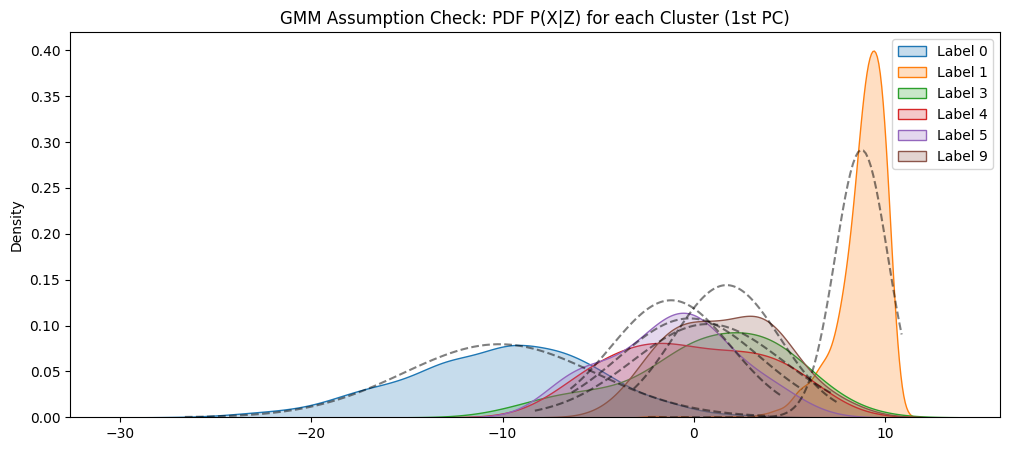

[Result] KMeans ARI: 0.6309
[Result] GMM ARI: 0.5320


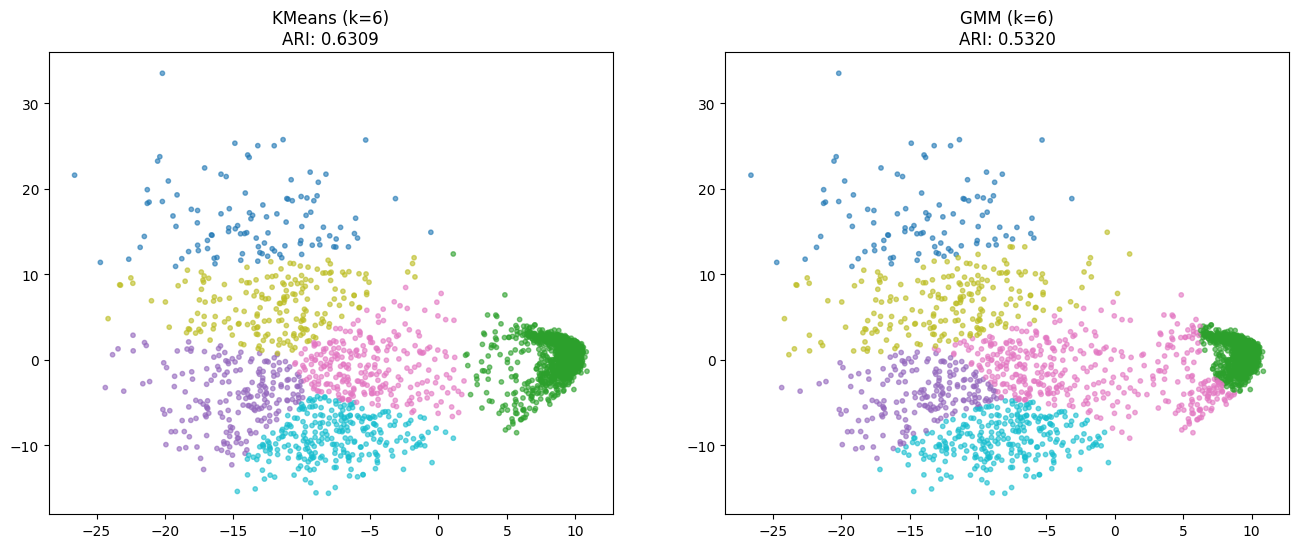

Reasoning: 
KMeans is suitable due to its simplicity and computational efficiency if clusters are roughly spherical.


In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score
from scipy.stats import norm

# 1. Setup Data & Known k
X = data_array_pca
true_labels = image_with_label['label']
k_known = len(np.unique(true_labels))

# --- 2. Check GMM Assumption (Normality of clusters) ---
# We look at the distribution of the 1st Principal Component for the true clusters
plt.figure(figsize=(12, 5))
for label in np.unique(true_labels):
    subset = X[true_labels == label, 0]
    sns.kdeplot(subset, label=f'Label {label}', fill=True)

    # Overlay ideal Normal distribution for comparison
    mu, std = norm.fit(subset)
    x_range = np.linspace(subset.min(), subset.max(), 100)
    plt.plot(x_range, norm.pdf(x_range, mu, std), color='black', linestyle='--', alpha=0.5)

plt.title("GMM Assumption Check: PDF P(X|Z) for each Cluster (1st PC)")
plt.legend()
plt.show()

# --- 3. Run Algorithms ---
# KMeans
kmeans = KMeans(n_clusters=k_known, random_state=0, n_init='auto').fit(X)
km_labels = kmeans.labels_
km_ari = adjusted_rand_score(true_labels, km_labels)

# GMM
gm = GaussianMixture(n_components=k_known, random_state=0).fit(X)
gm_labels = gm.predict(X)
gm_ari = adjusted_rand_score(true_labels, gm_labels)

# --- 4. Compare results ---
print(f"[Result] KMeans ARI: {km_ari:.4f}")
print(f"[Result] GMM ARI: {gm_ari:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(X[:, 0], X[:, 1], c=km_labels, cmap='tab10', s=10, alpha=0.6)
ax1.set_title(f"KMeans (k={k_known})\nARI: {km_ari:.4f}")

ax2.scatter(X[:, 0], X[:, 1], c=gm_labels, cmap='tab10', s=10, alpha=0.6)
ax2.set_title(f"GMM (k={k_known})\nARI: {gm_ari:.4f}")

plt.show()

# Reasoning for suitability
print("Reasoning: ")
if gm_ari > km_ari:
    print("GMM is more suitable as it accounts for elliptical cluster shapes (covariance) which we see in the PCA plot.")
else:
    print("KMeans is suitable due to its simplicity and computational efficiency if clusters are roughly spherical.")